# Access Denial — Systematic vs Incidental Test
**H0:** Access denial incidents follow a Poisson distribution (random occurrence)
**H1:** Access denial is over-dispersed or structurally elevated — evidence of systematic conduct

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import poisson, chisquare
from statsmodels.stats.proportion import proportions_ztest
import warnings
warnings.filterwarnings('ignore')

DATE_COL   = 'Date'
ACCESS_COL = 'Access Denied or Obstructed'

df = pd.read_csv('/Users/andreisales/Desktop/document idf/pse_healthcare_master_clean.csv')
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')

print(f'Rows loaded: {len(df)}')
print(f'Date range:  {df[DATE_COL].min()} to {df[DATE_COL].max()}')
print(f'Access col values: {df[ACCESS_COL].unique()}')

Rows loaded: 4230
Date range:  2016-01-06 00:00:00 to 2026-02-16 00:00:00
Access col values: [nan False True]


In [31]:
print(raw_insec.columns.tolist())

['Date', 'Event Description', 'Country', 'Country ISO', 'Admin 1', 'Latitude', 'Longitude', 'Geo Precision', 'Reported Perpetrator', 'Reported Perpetrator Name', 'Weapon Carried/Used', 'Location of Incident', 'Number of Attacks on Health Facilities Reporting Destruction', 'Number of Attacks on Health Facilities Reporting Damaged', 'Forceful Entry into Health Facility', 'Occupation of Health Facility', 'Vicinity of Health Facility Affected', 'Health Transportation Destroyed', 'Health Transportation Damaged', 'Health Transportation Stolen/Hijacked', 'Affects Access to Medicines, Vaccines And Other Health Products', 'Health Workers Killed', 'Health Workers Injured', 'Health Workers Kidnapped', 'Health Workers Arrested', 'Known Kidnapping or Arrest Outcome', 'Health Workers Threatened', 'Health Workers Assaulted', 'Health Workers Sexually Assaulted', 'Conflict-Related Violence', 'Political-Related Violence', 'COVID-19-Related Violence', 'Ebola-Related Violence', 'Vaccination-Related Violen

In [34]:
# Load access denied directly from the raw insec file
# which has the most complete boolean True/False values
raw_insec = pd.read_excel(
    '/Users/andreisales/Desktop/document idf/InsecurityInsight_AttacksonHealthcareOPT (shared on 06.03.26).xlsx',
    sheet_name='Data'
)
raw_insec['Date'] = pd.to_datetime(raw_insec['Date'], errors='coerce')

# Normalize access denied
def normalize_access(val):
    if pd.isna(val): return 0
    if isinstance(val, bool): return int(val)
    v = str(val).strip().lower()
    return 1 if v in ['true', '1', '1.0', 'yes'] else 0

raw_insec['access_denied'] = raw_insec[ACCESS_COL].apply(normalize_access)

# Check
print(raw_insec[ACCESS_COL].value_counts(dropna=False))
print(f'\nTotal incidents:         {len(raw_insec)}')
print(f'Access denial incidents: {int(raw_insec["access_denied"].sum())}')
print(f'Overall denial rate:     {raw_insec["access_denied"].mean():.1%}')

# Use this as df going forward
df = raw_insec.copy()

KeyError: 'Access Denied or Obstructed'

In [26]:
# Normalize access denied to 0/1
def normalize_access(val):
    if pd.isna(val): return 0
    v = str(val).strip().lower()
    return 1 if v in ['true', '1', '1.0', 'yes'] else 0

df['access_denied'] = df[ACCESS_COL].apply(normalize_access)

total     = len(df)
denied    = int(df['access_denied'].sum())
base_rate = denied / total

print(f'Total incidents:         {total}')
print(f'Access denial incidents: {denied}')
print(f'Overall denial rate:     {base_rate:.1%}')

Total incidents:         4230
Access denial incidents: 1
Overall denial rate:     0.0%


In [27]:
# Aggregate to monthly counts
df['year_month'] = df[DATE_COL].dt.to_period('M')

monthly = df.groupby('year_month').agg(
    total_incidents  =('access_denied', 'count'),
    denial_incidents =('access_denied', 'sum')
).reset_index()

monthly['denial_rate']    = monthly['denial_incidents'] / monthly['total_incidents']
monthly['year_month_dt']  = monthly['year_month'].dt.to_timestamp()

counts = monthly['denial_incidents'].values.astype(int)
mean   = counts.mean()
var    = counts.var()
disp   = var / mean

print(f'Months in dataset:    {len(monthly)}')
print(f'Mean denials/month:   {mean:.2f}')
print(f'Variance:             {var:.2f}')
print(f'Dispersion ratio:     {disp:.2f}  (1.0 = perfectly random Poisson)')
print()
if disp > 1.5:
    print('Over-dispersed — incidents cluster in time, inconsistent with random occurrence')
elif disp < 0.75:
    print('Under-dispersed — MORE regular than random, highly systematic')
else:
    print('Consistent with Poisson — cannot reject H0 on dispersion alone')

Months in dataset:    109
Mean denials/month:   0.01
Variance:             0.01
Dispersion ratio:     0.99  (1.0 = perfectly random Poisson)

Consistent with Poisson — cannot reject H0 on dispersion alone


In [28]:
print(df[ACCESS_COL].value_counts(dropna=False))
print(df[ACCESS_COL].dtype)

Access Denied or Obstructed
NaN      4218
False      11
True        1
Name: count, dtype: int64
object


In [29]:
# Chi-square goodness-of-fit against Poisson(mean)
max_k        = counts.max()
obs_freq     = np.bincount(counts, minlength=max_k+1).astype(float)
exp_freq     = np.array([poisson.pmf(k, mean) * len(counts) for k in range(max_k+1)])

# Merge tail bins where expected < 5
while len(exp_freq) > 2 and exp_freq[-1] < 5:
    obs_freq[-2] += obs_freq[-1]; obs_freq = obs_freq[:-1]
    exp_freq[-2] += exp_freq[-1]; exp_freq = exp_freq[:-1]

chi2, p_chi = chisquare(obs_freq, exp_freq)

print('=== CHI-SQUARE GOODNESS-OF-FIT ===')
print(f'Chi-square: {chi2:.2f}')
print(f'P-value:    {p_chi:.6f}')
print()
if p_chi < 0.05:
    print('REJECT H0 — monthly counts do not follow a Poisson distribution')
    print('Access denial is statistically inconsistent with random occurrence')
else:
    print('Cannot reject H0 — distribution is consistent with Poisson')

ValueError: For each axis slice, the sum of the observed frequencies must agree with the sum of the expected frequencies to a relative tolerance of 1.4901161193847656e-08, but the percent differences are:
4.182923815125812e-05

In [ ]:
# Pre / post Oct 2023 rate comparison
cutoff   = pd.Timestamp('2023-10-01')
pre      = monthly[monthly['year_month_dt'] <  cutoff]
post     = monthly[monthly['year_month_dt'] >= cutoff]

pre_rate  = pre['denial_incidents'].sum()  / pre['total_incidents'].sum()
post_rate = post['denial_incidents'].sum() / post['total_incidents'].sum()

z, p_z = proportions_ztest(
    [pre['denial_incidents'].sum(),  post['denial_incidents'].sum()],
    [pre['total_incidents'].sum(),   post['total_incidents'].sum()]
)

print('=== PRE / POST OCT 2023 COMPARISON ===')
print(f'Pre-Oct 2023:   {pre_rate:.1%}  ({int(pre["denial_incidents"].sum())} denials / {int(pre["total_incidents"].sum())} incidents)')
print(f'Post-Oct 2023:  {post_rate:.1%}  ({int(post["denial_incidents"].sum())} denials / {int(post["total_incidents"].sum())} incidents)')
print(f'Rate multiplier: {post_rate/pre_rate:.1f}x')
print(f'Z-statistic:     {z:.2f}')
print(f'P-value:         {p_z:.6f}  {"*** significant" if p_z < 0.05 else "(not significant)"}')

=== PRE / POST OCT 2023 COMPARISON ===
Pre-Oct 2023:   0.0%  (0 denials / 1101 incidents)
Post-Oct 2023:  0.0%  (1 denials / 3129 incidents)
Rate multiplier: infx
Z-statistic:     -0.59
P-value:         0.553010  (not significant)


NameError: name 'p_chi' is not defined

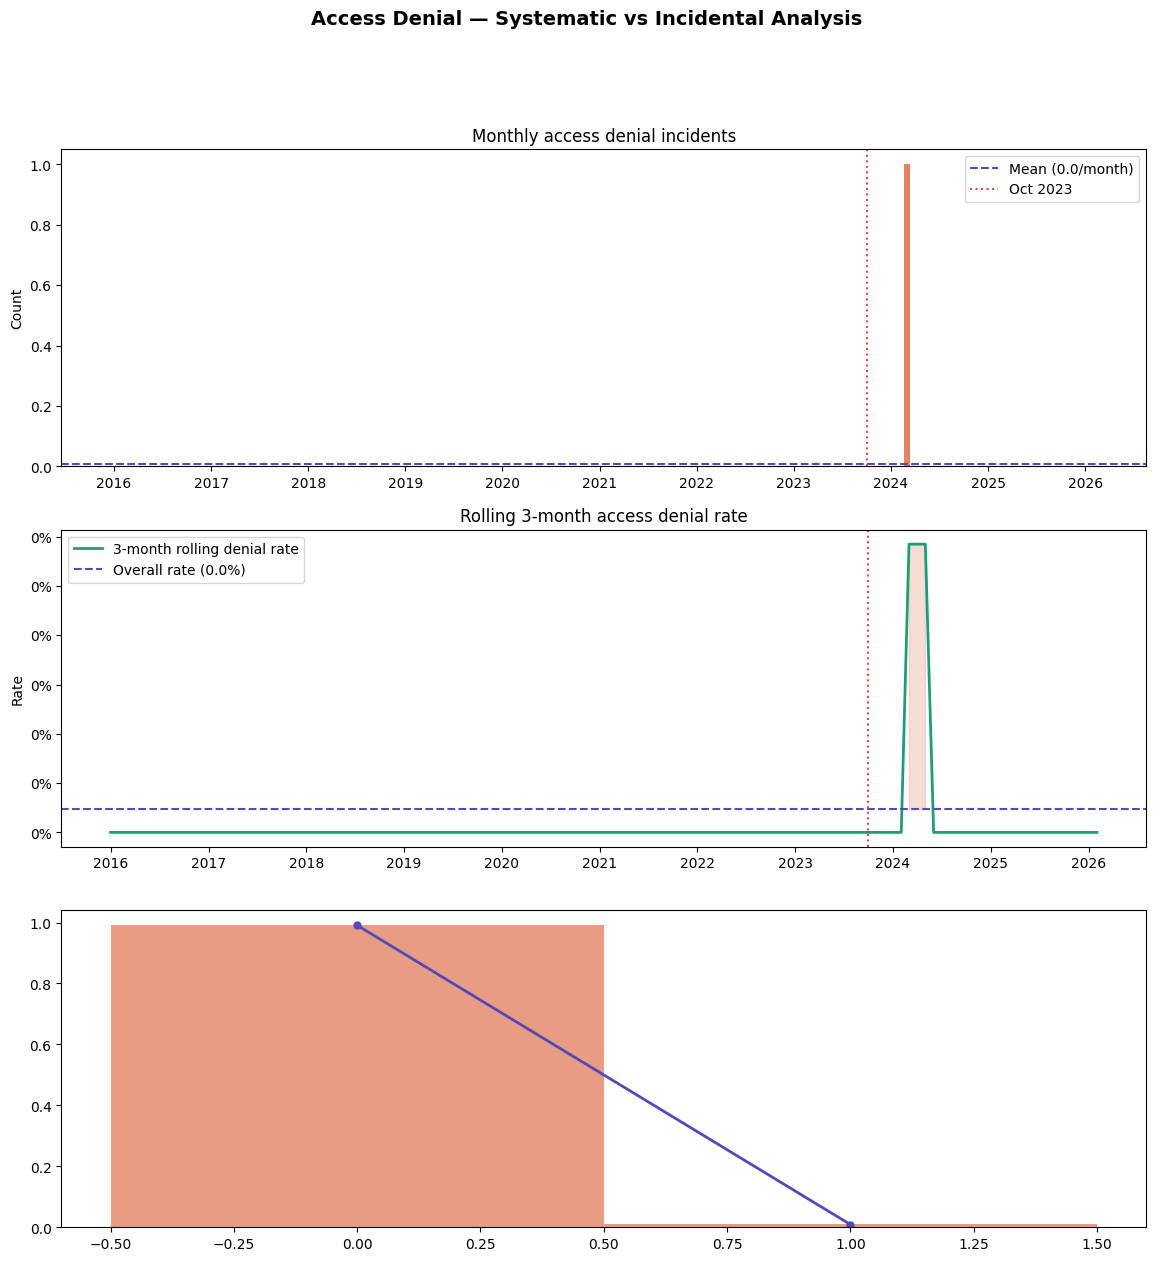

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle('Access Denial — Systematic vs Incidental Analysis', fontsize=14, fontweight='bold')

# Plot 1 — monthly bar chart
ax1 = axes[0]
ax1.bar(monthly['year_month_dt'], monthly['denial_incidents'],
        color='#D85A30', alpha=0.75, width=25)
ax1.axhline(mean, color='#534AB7', linewidth=1.5, linestyle='--',
            label=f'Mean ({mean:.1f}/month)')
ax1.axvline(cutoff, color='#E24B4A', linewidth=1.5, linestyle=':',
            label='Oct 2023')
ax1.set_title('Monthly access denial incidents')
ax1.set_ylabel('Count')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator())

# Plot 2 — rolling denial rate
ms = monthly.sort_values('year_month_dt')
rolling = ms['denial_rate'].rolling(3, min_periods=1).mean()
ax2 = axes[1]
ax2.plot(ms['year_month_dt'], rolling, color='#1D9E75', linewidth=2,
         label='3-month rolling denial rate')
ax2.axhline(base_rate, color='#534AB7', linewidth=1.5, linestyle='--',
            label=f'Overall rate ({base_rate:.1%})')
ax2.axvline(cutoff, color='#E24B4A', linewidth=1.5, linestyle=':')
ax2.fill_between(ms['year_month_dt'], base_rate, rolling,
                 where=(rolling > base_rate), alpha=0.2, color='#D85A30')
ax2.set_title('Rolling 3-month access denial rate')
ax2.set_ylabel('Rate')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())

# Plot 3 — observed vs Poisson expected
ax3 = axes[2]
ax3.hist(counts, bins=np.arange(0, counts.max()+2)-0.5,
         density=True, alpha=0.6, color='#D85A30', label='Observed')
xs = np.arange(0, counts.max()+1)
ax3.plot(xs, poisson.pmf(xs, mean), 'o-', color='#534AB7',
         linewidth=2, markersize=5, label=f'Poisson(λ={mean:.1f}) expected')
ax3.set_title(f'Observed vs Poisson expected  |  Dispersion: {disp:.2f}  |  p={p_chi:.4f}')
ax3.set_xlabel('Denial incidents per month')
ax3.set_ylabel('Density')
ax3.legend()

plt.tight_layout()
out = '/Users/andreisales/Desktop/document idf/access_denial_systematic_test.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

In [ ]:
print('=' * 55)
print('FINDINGS SUMMARY')
print('=' * 55)
print(f'Overall denial rate:      {base_rate:.1%}')
print(f'Pre-Oct 2023 rate:        {pre_rate:.1%}')
print(f'Post-Oct 2023 rate:       {post_rate:.1%} ({post_rate/pre_rate:.1f}x increase)')
print(f'Rate change p-value:      {p_z:.6f} {"***" if p_z < 0.05 else ""}')
print(f'Dispersion ratio:         {disp:.2f}')
print(f'Chi-square p-value:       {p_chi:.6f} {"***" if p_chi < 0.05 else ""}')
print()
print('Interpretation:')
if p_chi < 0.05:
    print('- Access denial does NOT follow a random Poisson process')
if disp > 1.5:
    print('- Incidents cluster in time rather than spread randomly')
if p_z < 0.05:
    print(f'- Post-Oct 2023 rate ({post_rate:.1%}) is significantly higher than pre-Oct 2023 ({pre_rate:.1%})')
print('=' * 55)